## 1. EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

plan for preprocessing: drop ID, check whether Gender carries signal, scale numerical features.

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

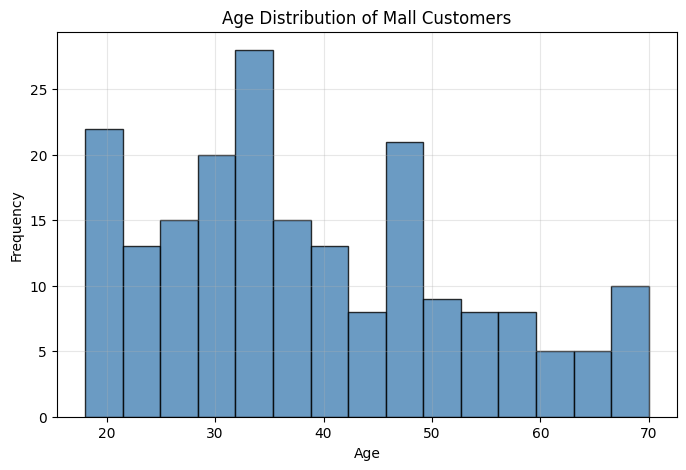

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Mall Customers')
plt.grid(axis='both', alpha=0.3)
plt.show()

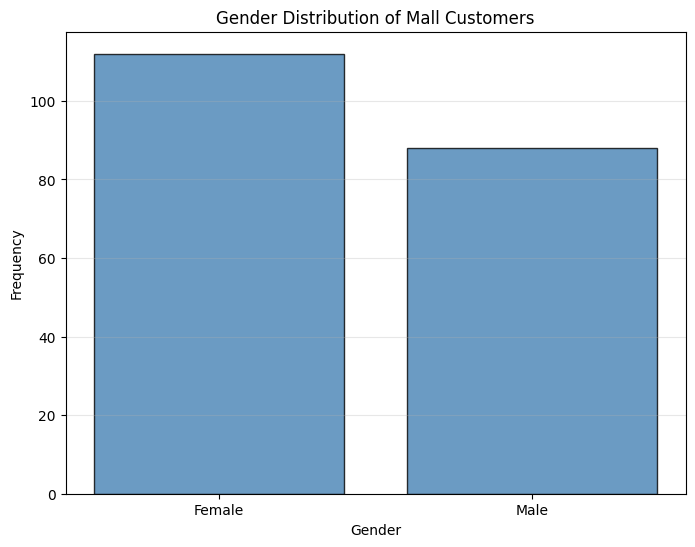

In [11]:
plt.figure(figsize=(8, 6))
plt.bar(df['Gender'].value_counts().index,df["Gender"].value_counts().values, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title('Gender Distribution of Mall Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

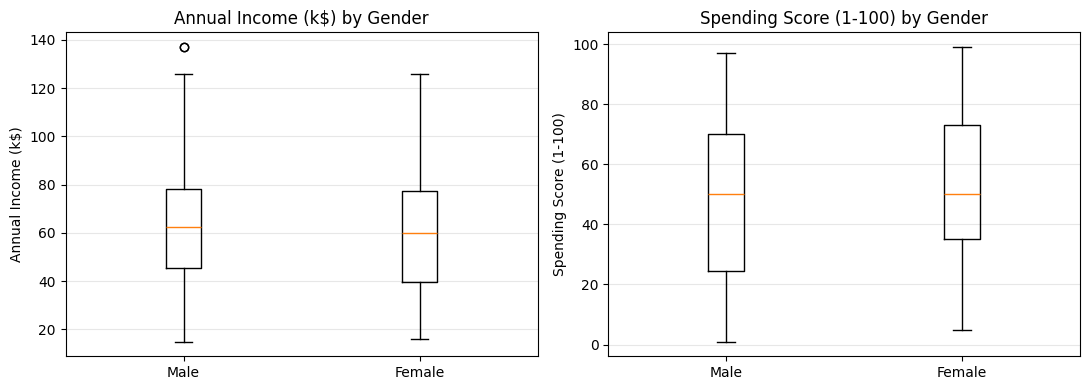

Age        Annual Income (k$)        Spending Score (1-100)       
        mean median               mean median                   mean median
Gender                                                                     
Female  38.1   35.0               59.2   60.0                   51.5   50.0
Male    39.8   37.0               62.2   62.5                   48.5   50.0

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for i, col in enumerate(['Annual Income (k$)', 'Spending Score (1-100)']):
    data = [df.loc[df['Gender'] == g, col] for g in ['Male', 'Female']]
    ax[i].boxplot(data)
    ax[i].set_xticks([1, 2], ['Male', 'Female'])
    ax[i].set_ylabel(col)
    ax[i].set_title(f'{col} by Gender')
    ax[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].agg(['mean', 'median']).round(1)

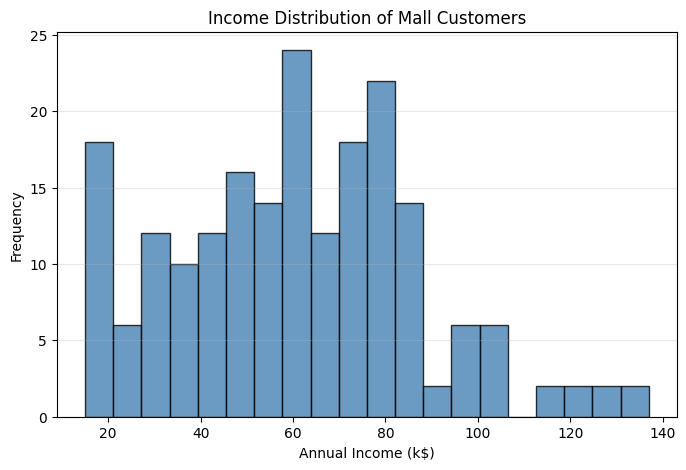

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df['Annual Income (k$)'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.title('Income Distribution of Mall Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

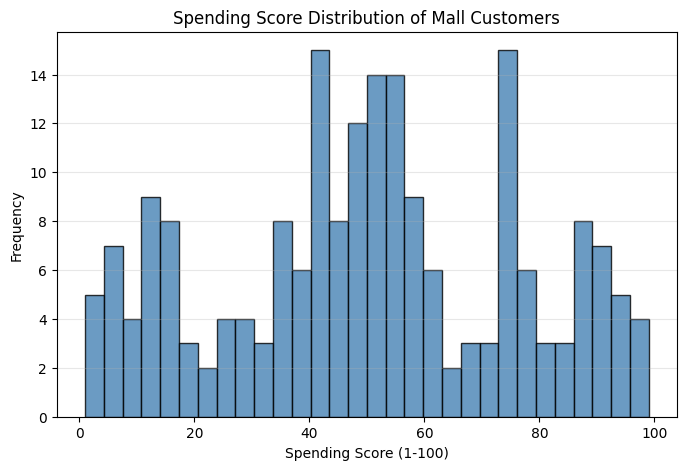

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['Spending Score (1-100)'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.title('Spending Score Distribution of Mall Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Preprocessing

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Feature selection

CustomerID was dropped. It's an arbitrary identifier with no relationship to behavior, and including it would just add noise to distance calculations.

Gender was dropped. The boxplots above show Income and Spending Score distributions overlapping almost completely: median income 60.0 for women against 62.5 for men, median spending score 50.0 for both. A 2.5k gap on a feature that runs 15 to 137 is not a segment boundary. Encoding Gender would add a dimension that separates every opposite-sex pair by a fixed distance while carrying no behavioral signal.

Age, Income, and Spending Score were kept. Segments here are defined by behavior.

Why Scaling Matters

KMeans clusters based on distance. Income spreads nearly twice as wide as Age (std 26.3 against 14.0, ranges 15 to 137 against 18 to 70), so unscaled, income differences dominate the distance calculation because the numbers are bigger, not because income matters more. StandardScaler puts all three features on equal footing (mean 0, std 1) so each contributes in proportion to its own variation.

## Finding K

In [17]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(best_k)

6


best k: 6   silhouette: 0.43


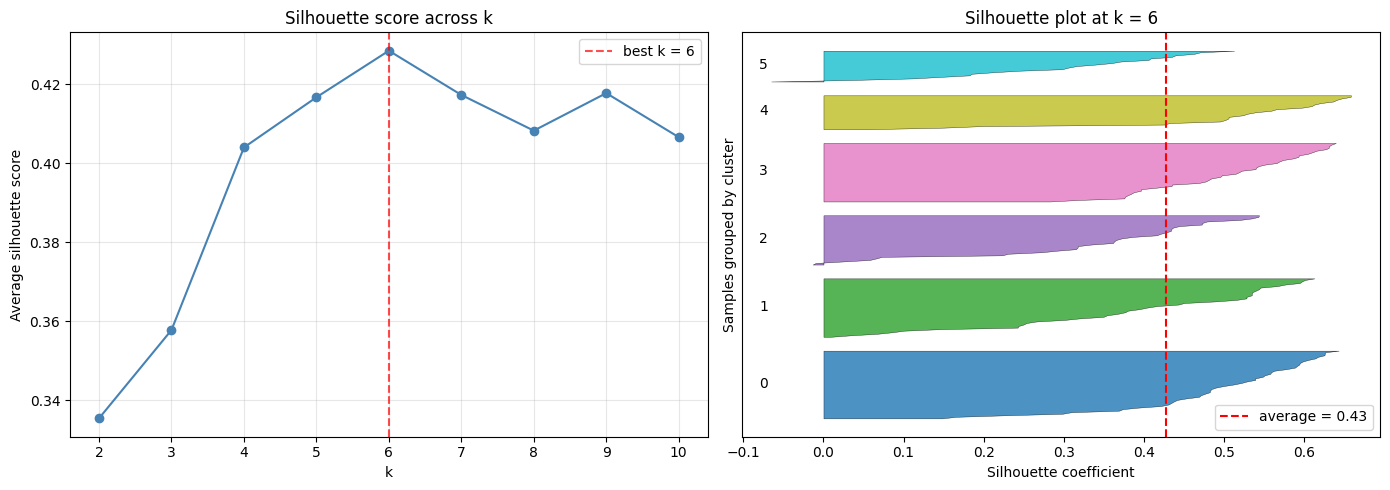

In [18]:
from sklearn.metrics import silhouette_samples
import numpy as np

best_score = max(silhouette_scores)
print(f"best k: {best_k}   silhouette: {best_score:.2f}")

best_labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(scaled_features)
sample_sil = silhouette_samples(scaled_features, best_labels)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(list(K_range), silhouette_scores, marker='o', color='steelblue')
ax[0].axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'best k = {best_k}')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Average silhouette score')
ax[0].set_title('Silhouette score across k')
ax[0].grid(alpha=0.3)
ax[0].legend()

y_lower = 0
for i in range(best_k):
    vals = np.sort(sample_sil[best_labels == i])
    y_upper = y_lower + len(vals)
    ax[1].fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                        color=plt.cm.tab10(i / (best_k - 1)), alpha=0.8,
                        edgecolor='black', linewidth=0.3)
    ax[1].text(-0.08, y_lower + len(vals) / 2, str(i), va='center')
    y_lower = y_upper + 8

ax[1].axvline(best_score, color='red', linestyle='--', label=f'average = {best_score:.2f}')
ax[1].set_xlabel('Silhouette coefficient')
ax[1].set_ylabel('Samples grouped by cluster')
ax[1].set_title(f'Silhouette plot at k = {best_k}')
ax[1].set_yticks([])
ax[1].legend()

plt.tight_layout()
plt.show()

Finding the best k

The elbow method alone is subjective, there's no single objective rule for where the "bend" is. Silhouette score was used instead: for each k from 2 to 10, KMeans was fit and the average silhouette score computed. k=6 gave the highest score (0.43).

The left panel above shows that peak directly, with no bend to eyeball. The right panel is the per-sample silhouette plot at k=6: all six clusters sit mostly to the right of the 0.43 average line, and sizes stay balanced at 45, 39, 33, 39, 23, and 21 members.

k=5 shows up again in the Model section. Clustering on Income and Spending Score alone selects k=5 on its own, which is the configuration most walkthroughs of this dataset use. The comparison against k=6 in 3D is below.

## Model

In [19]:
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = final_model.fit_predict(scaled_features)

In [20]:
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()
profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,56.3,54.3,49.1,45
1,26.8,57.1,48.1,39
2,41.9,88.9,17.0,33
3,32.7,86.5,82.1,39
4,25.0,25.3,77.6,23
5,45.5,26.3,19.4,21


In [21]:
scaled_2d = StandardScaler().fit_transform(df[['Annual Income (k$)', 'Spending Score (1-100)']])

scores_2d = [silhouette_score(scaled_2d, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(scaled_2d))
             for k in K_range]
best_k_2d = K_range[scores_2d.index(max(scores_2d))]
print(f"2D best k: {best_k_2d}   silhouette: {max(scores_2d):.2f}")

labels_2d = KMeans(n_clusters=best_k_2d, random_state=42, n_init=10).fit_predict(scaled_2d)
pd.crosstab(df['Cluster'], labels_2d, rownames=['3D cluster'], colnames=['2D cluster'])

2D best k: 5   silhouette: 0.55


2D cluster,0,1,2,3,4
3D cluster,,,,,
0,43,0,0,1,1
1,37,0,0,2,0
2,1,0,0,32,0
3,0,39,0,0,0
4,0,0,22,0,1
5,0,0,0,0,21


Cluster profiles

Cluster 0: older, average income, average spending
Cluster 1: young, average income, average spending
Cluster 2: high income, low spending. Careful with money
Cluster 3: high income, high spending. Prime target segment
Cluster 4: low income, high spending. Likely credit-reliant
Cluster 5: low income, low spending. Budget-conscious

Clusters 0 and 1 have nearly identical income (54.3 against 57.1) and nearly identical spending (49.1 against 48.1), separated by a 30-year age gap.

The crosstab above tests whether Age is doing real work rather than assuming it. Clustering on Income and Spending Score alone selects k=5 and collapses these two into one group: 43 of 45 and 37 of 39 land in the same 2D cluster, 80 of 84 customers merged. Adding Age splits them into segments that look identical on a spreadsheet and are a generation apart.

The 2D configuration scores higher on silhouette, 0.55 against 0.43. Those numbers are not comparable. They are computed in different feature spaces, and adding a dimension spreads points apart and depresses silhouette almost mechanically. A higher score in fewer dimensions is evidence of easier geometry, not better segmentation. k=6 in 3D was kept because it separates a group the 2D version cannot see.   

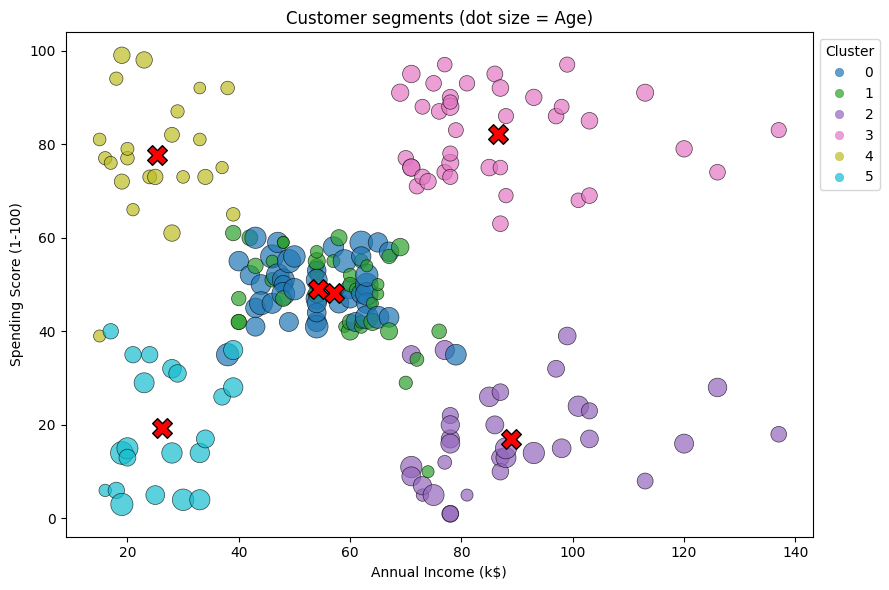

In [22]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='tab10',
    s=df['Age'] * 4,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

centers = scaler.inverse_transform(final_model.cluster_centers_)
plt.scatter(
    centers[:, 1], centers[:, 2],   # income, spending columns.
    c='red', marker='X', s=200, label='Centroids', edgecolors='black'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer segments (dot size = Age)')
plt.legend(*scatter.legend_elements(), title="Cluster", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Visualizing the clusters

Income and Spending Score are plotted directly, since those are the two axes that separate clusters most clearly. Age is encoded as dot size, since a third feature can't get its own axis on a 2D plot. Red X markers are the cluster centroids, inverse-transformed back to the original scale since the model was fit on scaled data.

The plot confirms the profile table. The smallest dots belong to cluster 4 (olive, mean age 25.0) and cluster 1 (green, 26.8). The largest belong to cluster 0 (blue, 56.3) and cluster 5 (cyan, 45.5).

Clusters 0 and 1 are the pair worth looking at. They sit almost on top of each other near the middle of the plot, and dot size is the only thing telling them apart. That overlap is what the 2D crosstab measured.

## PCA

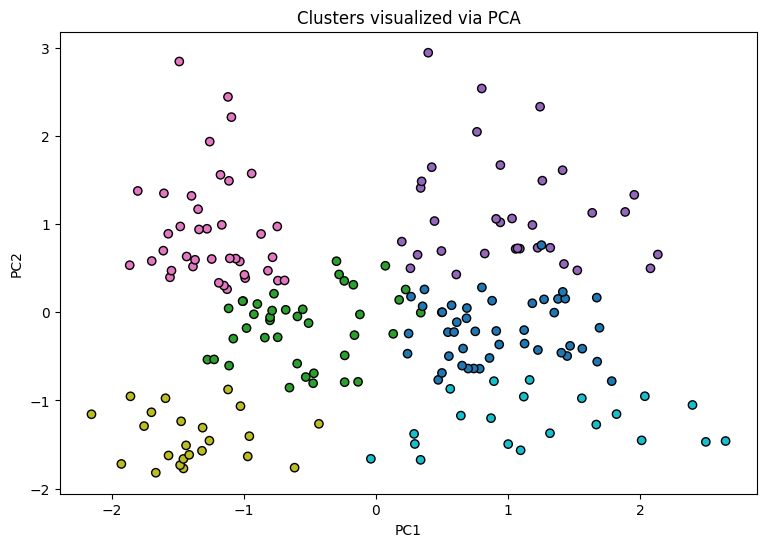

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(9, 6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=df['Cluster'], cmap='tab10', edgecolors='black')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters visualized via PCA')
plt.show()

PCA visualization

Clusters mostly stay separable in the PCA-reduced space, confirming the grouping isn't just an artifact of picking income and spending as plot axes.

Clusters 0 and 1 overlap more here than in the original plot. Their separation was mainly driven by age, and PCA compresses that signal across both PC1 and PC2 instead of keeping it explicit the way dot size did.